# DoubleIntegrator - Stage 4e - Multiple Obstacles: Barrier vs. PSF

Compare barrier adaptation and PSF with multiple obstacles.


## 1. Shared scenario and safety specification

Create the matched test scenario.


In [1]:
import copy
import sys
import time
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
_p = Path.cwd()
while not (_p / "src" / "sdpc").exists():
    _p = _p.parent
sys.path.insert(0, str(_p / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from sdpc.config import load_config
from sdpc.eval import compute_metrics, sample_scenario
from sdpc.plotting import plot_states_and_controls, plot_trajectories_with_obstacles
from sdpc.registry import make_system
from sdpc.sindy import load_model

SYSTEM = "double_integrator"
device = torch.device("cpu")
system = make_system(SYSTEM, device=device)
CONFIGS = Path.cwd().parent / "configs"
RESULTS = Path.cwd().parent / "results"

TRIAL_CONFIG = "multi_obstacle.yaml"
cfg = load_config(CONFIGS / TRIAL_CONFIG)
training_cfg = load_config(CONFIGS / "policy.yaml")

from sdpc.io import find_policy_checkpoint
policy_path = find_policy_checkpoint(RESULTS, cfg)
policy = load_model(policy_path, device=device)

data = sample_scenario(system, cfg, cfg.get("seed", 0), device)
plant = system.perturbed_plant(cfg)
derivative_model = system.perturbed_sindy_model(cfg)
spec = system.safety_specs(cfg)
obstacle_constraints = [
    con for con in spec.state_constraints
    if con.meta.get("kind") == "rotated_ellipse"
]

# Use the fixed comparison scenario from the YAML.
scenario = cfg["scenario"]
data["xn"] = torch.tensor(
    scenario["x0"], device=device, dtype=data["xn"].dtype
).view(1, 1, -1)
reference = torch.tensor(
    scenario["reference"], device=device, dtype=data["r"].dtype
)
data["r"] = reference.view(1, 1, -1).expand(
    data["r"].shape[0],
    data["r"].shape[1],
    -1,
).clone()

print("Configured reference:", data["r"][0, -1])
print("Initial rectangle :", cfg["init_center"], "side", cfg["init_side"])
print("Reference rectangle:", cfg["ref_center"], "side", cfg["ref_side"])
print("Sampled initial   :", data["xn"][0, 0].tolist())
print("Sampled reference :", data["r"][0, -1].tolist())
print("Obstacles         :", [con.name for con in obstacle_constraints])
print("Barrier obs. band :", cfg["bands"]["obstacle"])
print("PSF obs. buffer   :", cfg["psf"]["buffers"]["obstacle"])
print("Control-rate limit:", spec.control_rate.du_max)


Configured reference: tensor([-3.,  1.])
Initial rectangle : [3, -3] side 2.0
Reference rectangle: [-3, 3] side 2.0
Sampled initial   : [0.0, -3.200000047683716]
Sampled reference : [-3.0, 1.0]
Obstacles         : ['obstacle_1', 'obstacle_2', 'obstacle_3', 'obstacle_4']
Barrier obs. band : 0.2
PSF obs. buffer   : 0.2
Control-rate limit: 0.35


## 2. Why this placement

Place four small ellipses at arc-length samples of the unobstructed policy route.


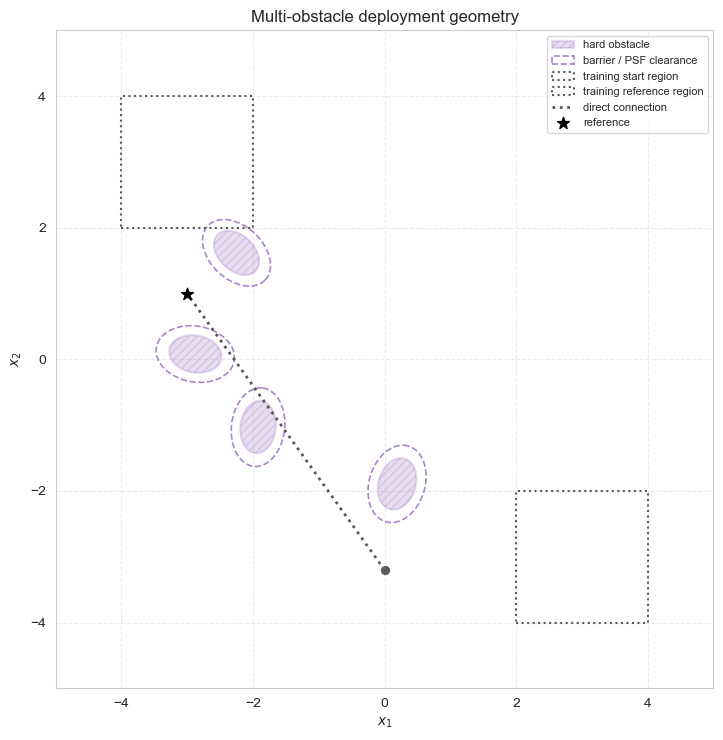

In [2]:
regions = [
    {"center": cfg["init_center"], "side": cfg["init_side"], "label": "training start region"},
    {"center": cfg["ref_center"], "side": cfg["ref_side"], "label": "training reference region"},
]

direct = torch.stack([data["xn"][0, 0], data["r"][0, -1]]).unsqueeze(0)
plot_trajectories_with_obstacles(
    [{"traj": direct, "label": "direct connection", "color": "0.35", "linestyle": ":"}],
    cfg["obstacles"], data["r"],
    obstacle_band=cfg["bands"]["obstacle"], regions=regions,
    xmin=-5, xmax=5, title="Multi-obstacle deployment geometry",
)
plt.show()


## 3. Run the common-policy comparisons

Compare the configured methods.


In [3]:
from sdpc.adaptation import UnconstrainedAdaptationConfig, run_unconstrained_adaptation

unc_values = {
    key: value for key, value in cfg["safe"].items()
    if key in UnconstrainedAdaptationConfig.__dataclass_fields__
}
unc_values["ref_backend"] = "autograd"
res_unsafe = run_unconstrained_adaptation(
    copy.deepcopy(policy), plant, data, UnconstrainedAdaptationConfig(**unc_values),
    umin=system.umin, umax=system.umax,
    derivative_model=derivative_model, system=system,
)


In [4]:
from sdpc.adaptation import SafeAdaptationConfig, run_safe_adaptation

safe_cfg = SafeAdaptationConfig(**cfg["safe"])

barrier_t0 = time.perf_counter()
res_barrier = run_safe_adaptation(
    copy.deepcopy(policy), plant, data, spec, safe_cfg,
    umin=system.umin, umax=system.umax,
    pred_plant=plant, derivative_model=derivative_model, system=system,
)
barrier_wall_s = time.perf_counter() - barrier_t0
print("Barrier predicted-safe steps:",
      sum(row["predicted_safe"] for row in res_barrier["logs"]),
      "/", len(res_barrier["logs"]))
print("Barrier safety iterations:", sum(row["safety_iters"] for row in res_barrier["logs"]))


Barrier predicted-safe steps: 300 / 300
Barrier safety iterations: 54


In [5]:
from sdpc.adaptation import PSFConfig, casadi_available, run_psf_adaptation

assert casadi_available(), "PSF requires CasADi in the neuromancer environment."
psf_cfg = PSFConfig(**cfg["psf"])
res_psf = run_psf_adaptation(
    copy.deepcopy(policy), plant, data, spec, psf_cfg,
    system=system, system_cfg=cfg,
    umin=system.umin, umax=system.umax,
)
print(f"PSF setup: {res_psf['setup_time_s']:.4f} s")
print(f"PSF online: {res_psf['wall_time_s']:.4f} s")
print("PSF realized violations:", sum(row["realized_violation"] for row in res_psf["logs"]))


PSF setup: 0.0271 s
PSF online: 2.3284 s
PSF realized violations: 0


## 4. Online-adaptation trajectories

Compare the executed trajectories.


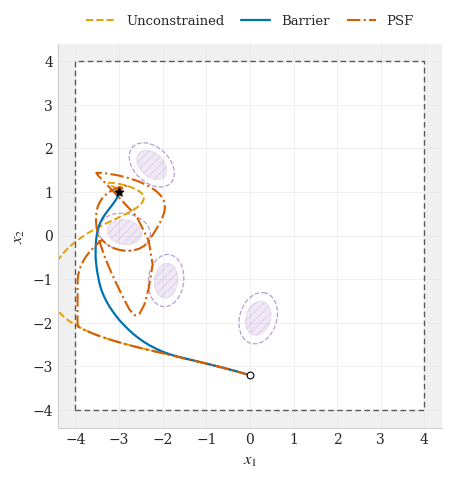

In [6]:
method_runs = {
    "unconstrained": res_unsafe,
    "barrier": res_barrier,
    "psf": res_psf,
}

output_stem = RESULTS / 'figures' / 'multi_obstacle_barrier_vs_psf'
fig, ax = plot_trajectories_with_obstacles(
    [
        {"traj": res_unsafe["x_traj"], "label": "Unconstrained", "color": "#E69F00",
         "linestyle": "--", "linewidth": 1.4, "show_start": False},
        {"traj": res_barrier["x_traj"], "label": "Barrier", "color": "#0072B2",
         "linestyle": "-", "linewidth": 1.6, "show_start": False},
        {"traj": res_psf["x_traj"], "label": "PSF", "color": "#D55E00",
         "linestyle": "-.", "linewidth": 1.5, "show_start": False},
    ],
    cfg["obstacles"], data["r"],
    obstacle_band=cfg["bands"]["obstacle"],
    state_bounds=(cfg.get("safe_xmin", system.xmin),
                  cfg.get("safe_xmax", system.xmax)), constraint_pad=0.4,
    publication=True, show_initial=True, reference_marker_size=38,
    title="", output_stem=str(output_stem),
)
plt.show()


In [ ]:
from IPython.display import Video, display
from sdpc.plotting import animate_trajectories_with_obstacles

video_path = RESULTS / "figures" / "multi_obstacle_barrier_vs_psf.mp4"

animate_trajectories_with_obstacles(
    [
        {"traj": res_unsafe["x_traj"], "label": "Unconstrained",
         "color": "#E69F00", "linestyle": "--", "linewidth": 1.4,
         "show_start": False},
        {"traj": res_barrier["x_traj"], "label": "Barrier",
         "color": "#0072B2", "linestyle": "-", "linewidth": 1.6,
         "show_start": False},
        {"traj": res_psf["x_traj"], "label": "PSF",
         "color": "#D55E00", "linestyle": "-.", "linewidth": 1.5,
         "show_start": False},
    ],
    obstacles=cfg["obstacles"],
    r=data["r"],
    obstacle_band=cfg["bands"]["obstacle"],
    state_bounds=(cfg.get("safe_xmin", system.xmin),
                  cfg.get("safe_xmax", system.xmax)),
    constraint_pad=0.4,
    publication=True,
    show_initial=True,
    reference_marker_size=38,
    title="",
    output_path=str(video_path),
    fps=20,
    dpi=150,
)

display(Video(str(video_path), embed=False, html_attributes="controls loop"))

## 5. Tracking, safety, smoothness, and computation

Compare performance and runtime metrics.


In [8]:
rows = []
for method, run in method_runs.items():
    metrics = compute_metrics(
        run["x_traj"], run["u_traj"], data["r"], spec=spec, logs=run.get("logs")
    )
    row = {
        "method": method,
        "tracking_mse": metrics["tracking_mse"],
        "final_error": torch.linalg.vector_norm(run["x_traj"][0, -1] - data["r"][0, -1]).item(),
        "state_violations": metrics["num_state_violations"],
        "du_violations": metrics.get("num_control_rate_violations", 0),
        "smooth_rms_du": metrics["control_smoothness_rms"],
        "max_du_l2": metrics["max_du_l2"],
        "online_s": metrics.get("runtime_total_s", np.nan),
        "online_ms_step": 1e3 * metrics.get("runtime_per_step_s", np.nan),
        "setup_s": run.get("setup_time_s", 0.0),
    }
    if method == "barrier":
        row["work_iterations"] = sum(log["safety_iters"] for log in run["logs"])
    elif method == "psf":
        row["work_iterations"] = sum(log["solver_iters"] for log in run["logs"])
    else:
        row["work_iterations"] = 0
    rows.append(row)

metrics_df = pd.DataFrame(rows).set_index("method")
display(metrics_df.round(5))

margin_rows = []
for method, run in method_runs.items():
    row = {"method": method}
    for con in obstacle_constraints:
        h = con.margin(run["x_traj"])
        row[f"{con.name}_hard_margin"] = float(h.min().item())
        row[f"{con.name}_clearance"] = float((h - con.band).min().item())
    margin_rows.append(row)
obstacle_margins_df = pd.DataFrame(margin_rows).set_index("method")
print("Per-obstacle minimum margins: hard safety requires >= 0; requested clearance requires >= 0")
display(obstacle_margins_df.round(5))


,tracking_mse,final_error,state_violations,du_violations,smooth_rms_du,max_du_l2,online_s,online_ms_step,setup_s,work_iterations
method,,,,,,,,,,
unconstrained,1.75480,0.00000,20,0,0.01412,0.04785,0.14756,0.49186,0.00000,0
barrier,1.41976,0.00000,0,0,0.00782,0.03628,0.93413,3.11377,0.00074,54
psf,2.10308,0.00012,0,0,0.06970,0.34278,2.32472,7.74906,0.02707,1479


Per-obstacle minimum margins: hard safety requires >= 0; requested clearance requires >= 0


,obstacle_1_hard_margin,obstacle_1_clearance,obstacle_2_hard_margin,obstacle_2_clearance,obstacle_3_hard_margin,obstacle_3_clearance,obstacle_4_hard_margin,obstacle_4_clearance
method,,,,,,,,
unconstrained,1.55294,1.35294,2.55941,2.35941,0.03394,-0.16606,0.77258,0.57258
barrier,1.55294,1.35294,2.22012,2.02012,0.20082,0.00082,1.59169,1.39169
psf,1.55317,1.35317,0.20000,0.00000,0.20000,0.00000,0.27546,0.07546


## 6. Per-obstacle clearance over time

Inspect safety diagnostics over time.


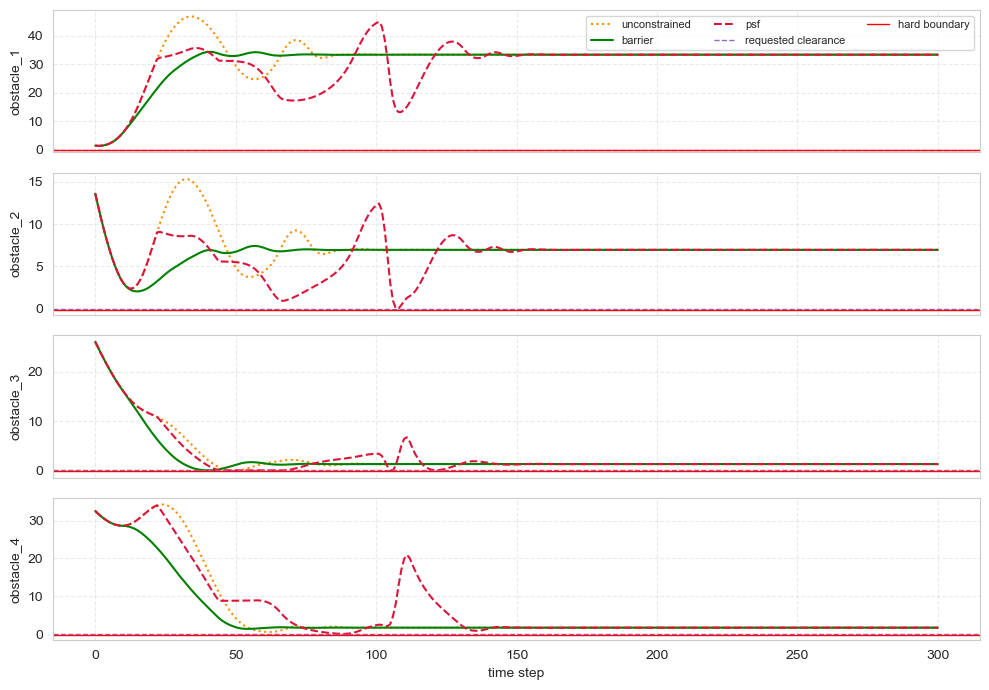

In [9]:
fig, axes = plt.subplots(len(obstacle_constraints), 1, figsize=(10, 7), sharex=True)
for ax, con in zip(axes, obstacle_constraints):
    for method, color, linestyle in (
        ("unconstrained", "darkorange", ":"),
        ("barrier", "green", "-"),
        ("psf", "crimson", "--"),
    ):
        clearance = con.margin(method_runs[method]["x_traj"])[0].detach().cpu() - con.band
        ax.plot(clearance, color=color, linestyle=linestyle, label=method)
    ax.axhline(0.0, color="tab:purple", linestyle="--", linewidth=1, label="requested clearance")
    ax.axhline(-con.band, color="red", linestyle="-", linewidth=1, label="hard boundary")
    ax.set_ylabel(con.name)
    ax.grid(True, linestyle="--", alpha=0.4)
axes[0].legend(ncol=3, fontsize=8)
axes[-1].set_xlabel("time step")
fig.tight_layout()
plt.show()


## 7. Applied states and controls

Compare the executed trajectories.


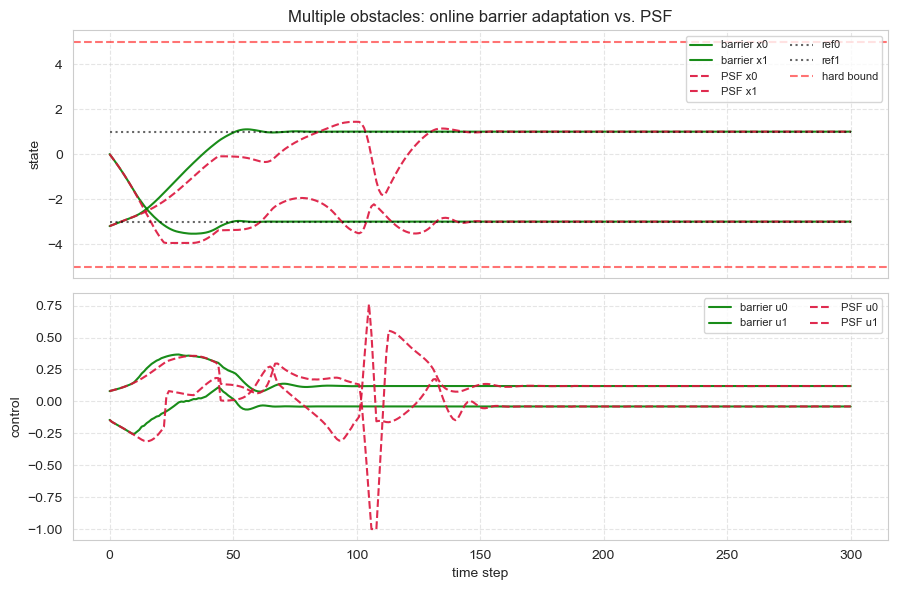

In [10]:
plot_states_and_controls(
    [
        {"x": res_barrier["x_traj"], "u": res_barrier["u_traj"], "label": "barrier", "color": "green"},
        {"x": res_psf["x_traj"], "u": res_psf["u_traj"], "label": "PSF", "color": "crimson", "linestyle": "--"},
    ],
    r_traj=data["r"], xmin=system.xmin, xmax=system.xmax,
    title="Multiple obstacles: online barrier adaptation vs. PSF",
)
plt.show()


## 8. Where each method spends computation

Compare runtime components.


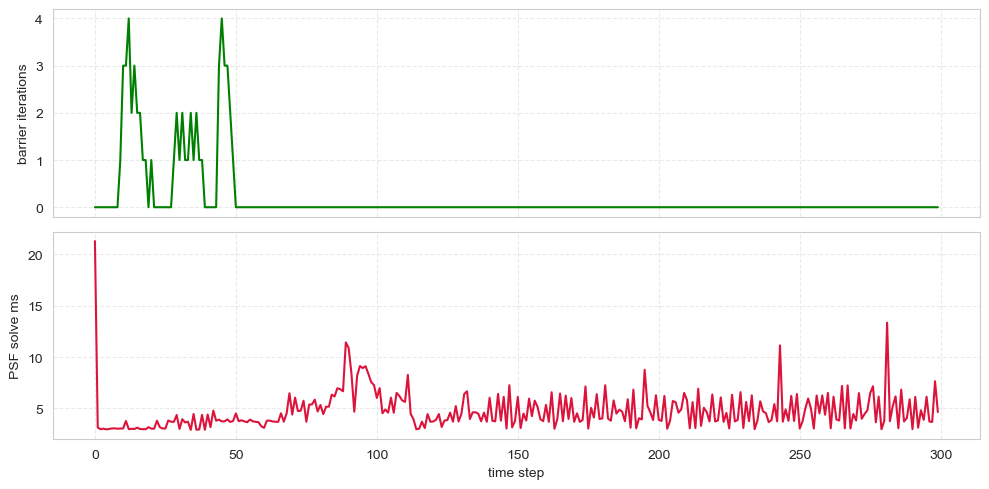

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot([row["safety_iters"] for row in res_barrier["logs"]], color="green")
axes[0].set_ylabel("barrier iterations")
axes[1].plot([1e3 * row["filter_time"] for row in res_psf["logs"]], color="crimson")
axes[1].set_ylabel("PSF solve ms")
axes[1].set_xlabel("time step")
for ax in axes:
    ax.grid(True, linestyle="--", alpha=0.4)
fig.tight_layout()
plt.show()


## 9. Export comparison tables

Compare the configured methods.


In [12]:
output_dir = RESULTS / "diagnostics"
output_dir.mkdir(parents=True, exist_ok=True)
metrics_path = output_dir / "multi_obstacle_barrier_vs_psf_metrics.csv"
margins_path = output_dir / "multi_obstacle_barrier_vs_psf_margins.csv"
metrics_df.to_csv(metrics_path)
obstacle_margins_df.to_csv(margins_path)
print("Saved:", metrics_path)
print("Saved:", margins_path)


Saved: /Users/alireza/Documents/PythonProject/gptSparseDPC/SparseDPC/6_Relative_Degree_One/DoubleIntegrator/results/diagnostics/multi_obstacle_barrier_vs_psf_metrics.csv
Saved: /Users/alireza/Documents/PythonProject/gptSparseDPC/SparseDPC/6_Relative_Degree_One/DoubleIntegrator/results/diagnostics/multi_obstacle_barrier_vs_psf_margins.csv


## Reading the comparison

Summarize the comparison.
